# Import Libraries and Functions

In [1]:
import sys
import importlib
import joblib
import os
import math
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.backends.backend_pdf import PdfPages
import time
from tqdm import tqdm
import gc

2026-09-09 13:46:17.459913: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-09 13:46:17.493634: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-09 13:46:17.493665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-09 13:46:17.494848: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 13:46:17.501262: I tensorflow/core/platform/cpu_feature_guar

In [2]:
sys.path.append("../analysis_tools")

In [3]:
# importlib.reload(data_extraction)
from data_extraction import DataExtraction2D
# import data_plot

# importlib.reload(data_plot)  
from data_plot import DataPlot

import data_calculation

# import modelData_processor
# importlib.reload(modelData_processor)
from modelData_processor import ModelDataProcessor

# import model_Analysis
# importlib.reload(model_Analysis)
from model_Analysis import ModelAnalysis

# importlib.reload(data_plot)  
from data_plot import DataPlot
from sklearn.metrics import r2_score, mean_squared_error

# Data Preparation

In [4]:
data_extractor = DataExtraction2D()

In [5]:
df_output = data_extractor.GetScenariosToPD(filename = "../Data/DUCK_SWAN_Data/swan_Log_DUCK.txt")

     Wind Value Wind Direction Wave Height Wave Direction  Iterations
0             1              0         1.6            -20          13
1             1              0         1.6              0          14
2             1              0         1.6             20          16
3             1              0         1.6             40          18
4             1              0         1.6             60          19
...         ...            ...         ...            ...         ...
3835          8            315         2.6             80          19
3836          8            315         2.6            100          18
3837          8            315         2.6            120          18
3838          8            315         2.6            140          15
3839          8            315         2.6            160          14

[3840 rows x 5 columns]


In [6]:
df_converged = df_output[df_output['Iterations'] != 50]
print(df_converged)

     Wind Value Wind Direction Wave Height Wave Direction  Iterations
0             1              0         1.6            -20          13
1             1              0         1.6              0          14
2             1              0         1.6             20          16
3             1              0         1.6             40          18
4             1              0         1.6             60          19
...         ...            ...         ...            ...         ...
3835          8            315         2.6             80          19
3836          8            315         2.6            100          18
3837          8            315         2.6            120          18
3838          8            315         2.6            140          15
3839          8            315         2.6            160          14

[3840 rows x 5 columns]


In [7]:
relevant_keys = set(
    zip(
        df_converged["Wind Value"].astype(int),
        df_converged["Wind Direction"].astype(int),
        df_converged["Wave Height"].astype(float),
        df_converged["Wave Direction"].astype(int),
    )
)

In [8]:
hsig_data = data_extractor.get_specific_data("../Data/DUCK_SWAN_Data/DUCK_training_hsig.txt", 'hsig', relevant_keys)
forces_data = data_extractor.get_specific_data("../Data/DUCK_SWAN_Data/DUCK_training_forces.txt", 'forces', relevant_keys)

In [9]:
df = data_extractor.DataConcat(relevant_keys, hsig_data, forces_data)

In [10]:
df_xp= pd.read_csv('../Data/DUCK_SWAN_Data/2d_duck_xp.txt', sep='\t', header=None)
df_yp= pd.read_csv('../Data/DUCK_SWAN_Data/2d_duck_yp.txt', sep='\t', header=None)
xp_vector = df_xp.values.flatten()
yp_vector = df_yp.values.flatten()

# RunTime Analysis

In [12]:
import pandas as pd
import re

def load_swan_timing(file_path):
    data = []
    with open(file_path, 'r') as f:
        # Skip the header line
        next(f) 
        for line in f:
            # Use regex to find the tuple and the duration
            # Matches: (values), duration
            match = re.search(r'\((.*?)\),\s*([\d\.]+)', line)
            if match:
                key_str = match.group(1) # "4, 45, 1.8, 80"
                duration = float(match.group(2))
                
                # Convert the key string into a tuple of floats/ints
                key = tuple(float(x.strip()) for x in key_str.split(','))
                data.append({'key': key, 'swan_time': duration})
    
    return pd.DataFrame(data)

# Usage
swan_timing_df = load_swan_timing('../Data/DUCK_SWAN_Data/DUCK_execution_times.txt')
print(swan_timing_df.head())

                       key   swan_time
0   (1.0, 0.0, 2.2, -20.0)   88.374085
1   (4.0, 45.0, 1.8, 80.0)  137.075454
2  (5.0, 225.0, 2.6, 20.0)  109.621452
3   (1.0, 90.0, 1.8, 40.0)  132.059077
4  (6.0, 135.0, 2.2, 60.0)  133.987413


In [13]:
fineGrid_swan_timing_df = load_swan_timing('../Data/DUCK_SWAN_CrossGridValidation/fineGrid_DUCK_execution_times.txt')
print(swan_timing_df.head())

                       key   swan_time
0   (1.0, 0.0, 2.2, -20.0)   88.374085
1   (4.0, 45.0, 1.8, 80.0)  137.075454
2  (5.0, 225.0, 2.6, 20.0)  109.621452
3   (1.0, 90.0, 1.8, 40.0)  132.059077
4  (6.0, 135.0, 2.2, 60.0)  133.987413


In [14]:
total_seconds = swan_timing_df['swan_time'].sum()

# 2. Convert seconds to hours (1 hour = 3600 seconds)
total_hours = total_seconds / 3600
print(f"Total Computation Time (Hours):   {total_hours:,.2f} hours")

Total Computation Time (Hours):   17.72 hours


In [15]:
total_seconds = fineGrid_swan_timing_df['swan_time'].sum()

# 2. Convert seconds to hours (1 hour = 3600 seconds)
total_hours = total_seconds / 3600
print(f"Total Computation Time (Hours):   {total_hours:,.2f} hours")

Total Computation Time (Hours):   36.96 hours


In [15]:
def convert_wind_components(speed, direction):
    # Convert wind direction to radians
    direction_rad = np.deg2rad(direction)
    # Calculate x and y components of the wind speed
    x_wind = speed * np.cos(direction_rad)
    y_wind = speed * np.sin(direction_rad)
    return x_wind, y_wind

def load_and_scale_new_data(new_b_train, scaler_path_0_1, scaler_path_2):
        """
        Load the saved scalers and apply scaling to new data.
        
        Parameters:
        - new_b_train: np.array, new input data 
        - scaler_path_0_1: str, path to load MinMaxScaler for columns 0 and 1.
        - scaler_path_2: str, path to load MinMaxScaler for column 2.
        
        Returns:
        - new_b_train_scaled: np.array, scaled new data.
        """
        # Load the saved MinMaxScaler for columns 0 and 1
        scaler_0_1 = joblib.load(scaler_path_0_1)
        
        # Load the saved MinMaxScaler for column 2
        scaler_2 = joblib.load(scaler_path_2)
        
        # # Load the custom scaling factor for column 3
        # scaling_factor_3 = joblib.load(scaler_path_3)
        
        # Apply scaling to columns 0 and 1 using the loaded scaler
        new_scaled_0_1 = scaler_0_1.transform(new_b_train[:, [0, 1]])
        
        # Apply scaling to column 2 using the loaded scaler
        new_scaled_2 = scaler_2.transform(new_b_train[:, [2]].reshape(-1, 1))
        
        
        # Combine the scaled columns back together
        new_b_train_scaled = np.hstack((new_scaled_0_1, new_scaled_2, new_b_train[:, [3, 4]]))
        
        return new_b_train_scaled


def trunk_scale_and_reload(t_train, t_val=None, save_scalers=True, reload_scalers=False, scaler_path_0=None, scaler_path_1=None):
    """
    Scales t_train and optionally t_val columns independently to range [0, 1],
    with the ability to save and reload scalers.
    
    Args:
        t_train (numpy.ndarray): Training data with two columns to scale.
        t_val (numpy.ndarray, optional): Validation data with two columns to scale. Defaults to None.
        save_scalers (bool): Whether to save the scalers for later use. Defaults to True.
        reload_scalers (bool): Whether to reload scalers from the provided paths. Defaults to False.
        scaler_path_0 (str): Path to save or reload the scaler for column 0.
        scaler_path_1 (str): Path to save or reload the scaler for column 1.
    
    Returns:
        tuple: Scaled t_train and optionally t_val arrays.
    """
    # Initialize scalers
    if reload_scalers:
        # Reload saved scalers
        if scaler_path_0 and scaler_path_1:
            scaler_col_0 = joblib.load(scaler_path_0)
            scaler_col_1 = joblib.load(scaler_path_1)
        else:
            raise ValueError("Scaler paths must be provided for reloading scalers.")
    else:
        # Initialize new scalers for each column
        scaler_col_0 = MinMaxScaler(feature_range=(0, 1))  # For column 0
        scaler_col_1 = MinMaxScaler(feature_range=(0, 1))  # For column 1
        
        # Fit scalers on t_train
        scaler_col_0.fit(t_train[:, 0].reshape(-1, 1))
        scaler_col_1.fit(t_train[:, 1].reshape(-1, 1))
        
        # Save scalers if required
        if save_scalers:
            if scaler_path_0:
                joblib.dump(scaler_col_0, scaler_path_0)
            if scaler_path_1:
                joblib.dump(scaler_col_1, scaler_path_1)
    
    # Scale t_train using the scalers
    t_train_scaled_col_0 = scaler_col_0.transform(t_train[:, 0].reshape(-1, 1))
    t_train_scaled_col_1 = scaler_col_1.transform(t_train[:, 1].reshape(-1, 1))
    t_train_scaled = np.hstack([t_train_scaled_col_0, t_train_scaled_col_1])
    
    # Scale t_val if provided
    if t_val is not None:
        t_val_scaled_col_0 = scaler_col_0.transform(t_val[:, 0].reshape(-1, 1))
        t_val_scaled_col_1 = scaler_col_1.transform(t_val[:, 1].reshape(-1, 1))
        t_val_scaled = np.hstack([t_val_scaled_col_0, t_val_scaled_col_1])
        return t_train_scaled, t_val_scaled
    
    return t_train_scaled

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
with open("../Data/DUCK_SWAN_Data/DUCK_dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

train_data = loaded_data["train"]
val_data = loaded_data["val"]
test_data = loaded_data["test"]

In [18]:
df["key"] = list(zip(df["Wind Value"], df["Wind Direction"], df["Wave Height"], df["Wave Direction"]))
test_df = df[df["key"].isin(test_data)]

In [19]:
model_dir = "../Models/model_DUCK_Hsig"
model = tf.keras.models.load_model(model_dir, compile=False)
target_scaler = joblib.load(f"{model_dir}/target_scaler.pkl")
don_timing_results = []

for _, row in test_df.iterrows():
    hsig_data_coarse = np.array(row["Hsig Data"])
    valid_mask = (hsig_data_coarse >= 0) 
    valid_idx = np.where(valid_mask)[0]

    
    b_key = list(row["key"])
    x_wind, y_wind = convert_wind_components(b_key[0], b_key[1])
    cos_w = np.cos(np.radians(b_key[3]))
    sin_w = np.sin(np.radians(b_key[3]))
    b_raw = np.array([[x_wind, y_wind, b_key[2], cos_w, sin_w]], dtype=np.float32)

    # 3. Scale Branch
    b_test_scaled = load_and_scale_new_data(
        b_raw,
        scaler_path_0_1=f"{model_dir}/scaler_factor_0_1.pkl",
        scaler_path_2=f"{model_dir}/scaler_factor_2.pkl",
    )

    # 4. Prepare and Scale Trunk (The coordinates)
    valid_xy = np.column_stack((xp_vector[valid_idx], yp_vector[valid_idx]))
    t_test_scaled = trunk_scale_and_reload(
        valid_xy,
        scaler_path_0=f"{model_dir}/scaler_col_0.pkl",
        scaler_path_1=f"{model_dir}/scaler_col_1.pkl",
    )

    start_time = time.perf_counter()
    o_res = model([b_test_scaled, t_test_scaled])
    end_time = time.perf_counter()
    

    pred_valid = target_scaler.inverse_transform(o_res.numpy()).flatten()

    elapsed = end_time - start_time
 
    key = tuple(float(x) for x in row["key"])
    scenario_result = {"key": key, "deepONet_time": elapsed}
    don_timing_results.append(scenario_result)
don_timing_df = pd.DataFrame(don_timing_results)

2026-06-11 13:03:43.269865: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43475 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:be:00.0, compute capability: 8.9
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
2026-06-11 13:03:44.238662: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3

In [20]:
print(don_timing_df)

                         key  deepONet_time
0     (4.0, 45.0, 1.8, 80.0)       0.316680
1     (1.0, 90.0, 2.0, 40.0)       0.004533
2    (4.0, 270.0, 2.6, 20.0)       0.004671
3     (3.0, 180.0, 1.8, 0.0)       0.004586
4    (4.0, 270.0, 1.6, 60.0)       0.001603
..                       ...            ...
571  (5.0, 180.0, 2.4, 20.0)       0.001852
572  (5.0, 225.0, 2.2, 80.0)       0.001841
573  (7.0, 45.0, 2.0, 120.0)       0.001843
574    (1.0, 0.0, 2.4, 40.0)       0.002093
575   (2.0, 0.0, 1.6, -20.0)       0.001864

[576 rows x 2 columns]


In [21]:
import pandas as pd

# 1. Merge the dataframes on the 'key' tuple
comparison_df = pd.merge(swan_timing_df, don_timing_df, on='key')

# 2. Calculate the Improvement Metrics
# Absolute difference in seconds
comparison_df['time_saved'] = comparison_df['swan_time'] - comparison_df['deepONet_time']

# Speedup factor (Swan / DON)
comparison_df['speedup'] = comparison_df['swan_time'] / comparison_df['deepONet_time']

# 3. Display Results
print(comparison_df[['key', 'swan_time', 'deepONet_time', 'speedup']])

# 4. Global Summary
avg_speedup = comparison_df['speedup'].mean()
print(f"\nOverall Improvement: DeepONet is average {avg_speedup:,.2f}x faster than SWAN.")

                          key   swan_time  deepONet_time       speedup
0      (1.0, 0.0, 2.2, -20.0)   88.374085       0.001830  48284.463486
1      (4.0, 45.0, 1.8, 80.0)  137.075454       0.316680    432.851175
2     (5.0, 225.0, 2.6, 20.0)  109.621452       0.001827  59984.806337
3      (1.0, 90.0, 1.8, 40.0)  132.059077       0.001831  72136.191754
4     (6.0, 135.0, 2.2, 60.0)  133.987413       0.001851  72372.931853
..                        ...         ...            ...           ...
571  (4.0, 315.0, 1.6, 140.0)   80.841401       0.001823  44334.043863
572   (5.0, 45.0, 1.6, 100.0)  123.454978       0.001860  66362.939791
573    (2.0, 0.0, 1.6, -20.0)   70.265131       0.001864  37698.252209
574  (6.0, 180.0, 2.0, 120.0)  111.353008       0.001843  60435.760378
575  (8.0, 225.0, 1.6, 160.0)   50.034451       0.001829  27363.135701

[576 rows x 4 columns]

Overall Improvement: DeepONet is average 59,199.61x faster than SWAN.


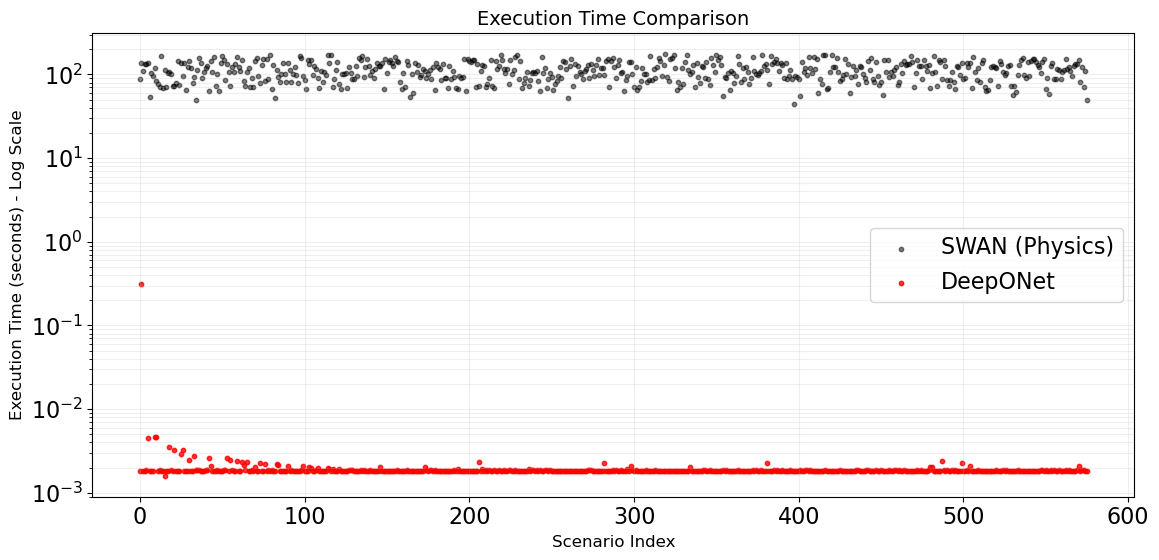

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Sort scenarios by SWAN time to make the plot easier to read
# df_sorted = comparison_df.sort_values('swan_time').reset_index()

plt.scatter(comparison_df.index, comparison_df['swan_time'], label='SWAN (Physics)', color='black', s=10, alpha=0.5)
plt.scatter(comparison_df.index, comparison_df['deepONet_time'], label='DeepONet', color='red', s=10, alpha=0.8)

plt.yscale('log')
plt.xlabel('Scenario Index', fontsize=12)
plt.ylabel('Execution Time (seconds) - Log Scale', fontsize=12)
plt.title('Execution Time Comparison', fontsize=14)
plt.legend(loc='best')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("Execution_time.pdf")
plt.show()